# Wildfire Intensity Prediction
#### By Damiru Vidunitha Wanniarachchi (S4137361)

---

## How to Run
1. Place `wildfire_cls_train_full.csv` and `wildfire_cls_test_features.csv` in the same directory as this notebook
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`).
3. The final cell saves `test_predictions.csv`.

---

# 1.0 Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip3.11 install --upgrade pip


In [2]:
# Standard library
import warnings
warnings.filterwarnings('ignore')
import random
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Reproducibility
SEED = 7
random.seed(SEED)
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
FIGSIZE = (10, 5)

CLASS_NAMES = ['Low (0)', 'Moderate (1)', 'High (2)', 'Extreme (3)']

print('All imports successful.')

All imports successful.


# 2.0 Data

## 2.1 Load Data

In [ ]:
df_tr = pd.read_csv('dataset/wildfire_cls_train_full.csv')
df_te  = pd.read_csv('dataset/wildfire_cls_test_features.csv')

## 2.2 Exploratory Data Analysis (EDA)

### Overview of Data

In [5]:
print(f'Training set : {df_tr.shape[0]:,} rows × {df_tr.shape[1]} columns')
print(f'Test set     : {df_te.shape[0]:,} rows × {df_te.shape[1]} columns')

Training set : 4,340 rows × 20 columns
Test set     : 1,085 rows × 19 columns


The above shows that the *training dataset* contains 4340 entries and 20 features, whereas the *test dataset* contains 1085 entries and 19 features excluding the target variable `fire_intensity`.

In [6]:
df_tr.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [14]:
print('\nColumn dtypes\n')
print(df_tr.dtypes)
print('\nBasic statistics')
df_tr.describe(include='all').T


Column dtypes

latitude          float64
longitude         float64
acq_date              str
acq_time            int64
year                int64
month             float64
season                str
daynight              str
region                str
country               str
fire_type             str
satellite             str
instrument            str
brightness_k      float64
confidence            str
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
fire_intensity        str
dtype: object

Basic statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitude,4340.0,NaN,NaN,NaN,9.821703,24.321271,-42.9883,-8.611625,10.2685,29.011025,69.9309
longitude,4340.0,NaN,NaN,NaN,29.430626,78.8427,-167.9906,-40.9806,34.8337,95.166775,153.7549
acq_date,4340,709,2025-08-26,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acq_time,4340.0,NaN,NaN,NaN,1177.046774,683.844117,0.0,602.0,1208.0,1752.0,2359.0
year,4340.0,NaN,NaN,NaN,2024.501843,0.500054,2024.0,2024.0,2025.0,2025.0,2025.0
month,3924.0,NaN,NaN,NaN,7.240316,2.791615,1.0,5.0,8.0,9.0,12.0
season,4340,4,Spring,1333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daynight,4340,2,D,2392,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,4340,7,South_Asia,895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,4340,35,Australia,275,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `count` statistic presents the number of non-null values in the dataset for each feature. The above `count`s indicate the presence of **missing data** which should be analysed and handled appropriately.

It is important to note that 10 unique classes (types) of fires exist for the `fire_type` variable, indicating significant diversity of environmental contexts of these fires.

The most frequent `fire_intensity` (target variable) recorded is shown to be of 'Moderate' intensity.

The dataset is made up of wildfire data from 35 countries, giving it a more global perspective.

### Target class distribution

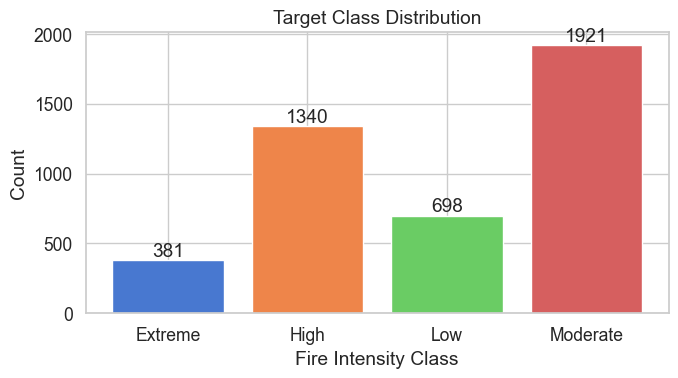

fire_intensity
Extreme      381
High        1340
Low          698
Moderate    1921
Name: count, dtype: int64


In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_tr['fire_intensity'].value_counts().sort_index()
bars = ax.bar(vc.index, vc.values, color=sns.color_palette('muted', 4))
ax.bar_label(bars, fmt='%d')
ax.set_title('Target Class Distribution')
ax.set_xlabel('Fire Intensity Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(vc)

The dataset is heavily skewed towards the 'Moderate' `fire_intensity` which accounts for about $45%$ of the total samples. Whereas the minority is shown to be fires of 'Extreme' intensity.

Due to the significant imbalance of classes, the metric **Accuracy** would be misleading. A naive model that over predicts the 'Moderate' class would noticably achieve a higher accuracy while failing to identify fires of the more high-risk class 'Extreme'.

In ensuring the model reliability in predicting across all fire intensities, **Macro F1-score** would be prioritized. This is due to Macro F1-score treating all classes with equal importance unlike a weighted F1-score.

### Missing values

In [25]:
missing = df_tr.isnull().sum()
missing_pct = (missing / len(df_tr) * 100).round(2)
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(f'\nMissing value analysis\n')
print(mv[mv['Missing Count'] > 0])

# ANALYSIS NOTE ─────────────────────────────────────────────────────────────
# List which columns have missing values and the %. For numeric columns
# with <5% missing, mean/median imputation is commonly justified. For
# categorical columns, use the mode. Justify your choice here.


Missing value analysis

              Missing Count  Missing %
month                   416       9.59
brightness_k            327       7.53
wind_max_kmh            207       4.77


The check above reveals 3 features with missing values: `month`, `brightness_k`, `wind_max_kmh`. None of the features have more than $10%$ of missing data, making them suitable for imputation.

*Numerical features (`brightness_k`, `wind_max_kmh`):*
> Both `brightness_k` and `wind_max_kmh` are prone to extreme outliers as well as environmental variables. Since the **Means** of these features are sensitive to those outliers, the **Median inputation** method is chosen. This would maintain the integrity of the data distribution by acting as a robust measure of central tendency.

*Categorical features (`month`):*
> `month`, a descrete variable represents a specific time period. If imputed with a non-integer mean, it would result in logical inconsistencies. Therefore, the **Mode imputation** method would be used to ensure the imputed values remain within the valid range of the feature `month`'s distribution.

### Numeric feature distribution

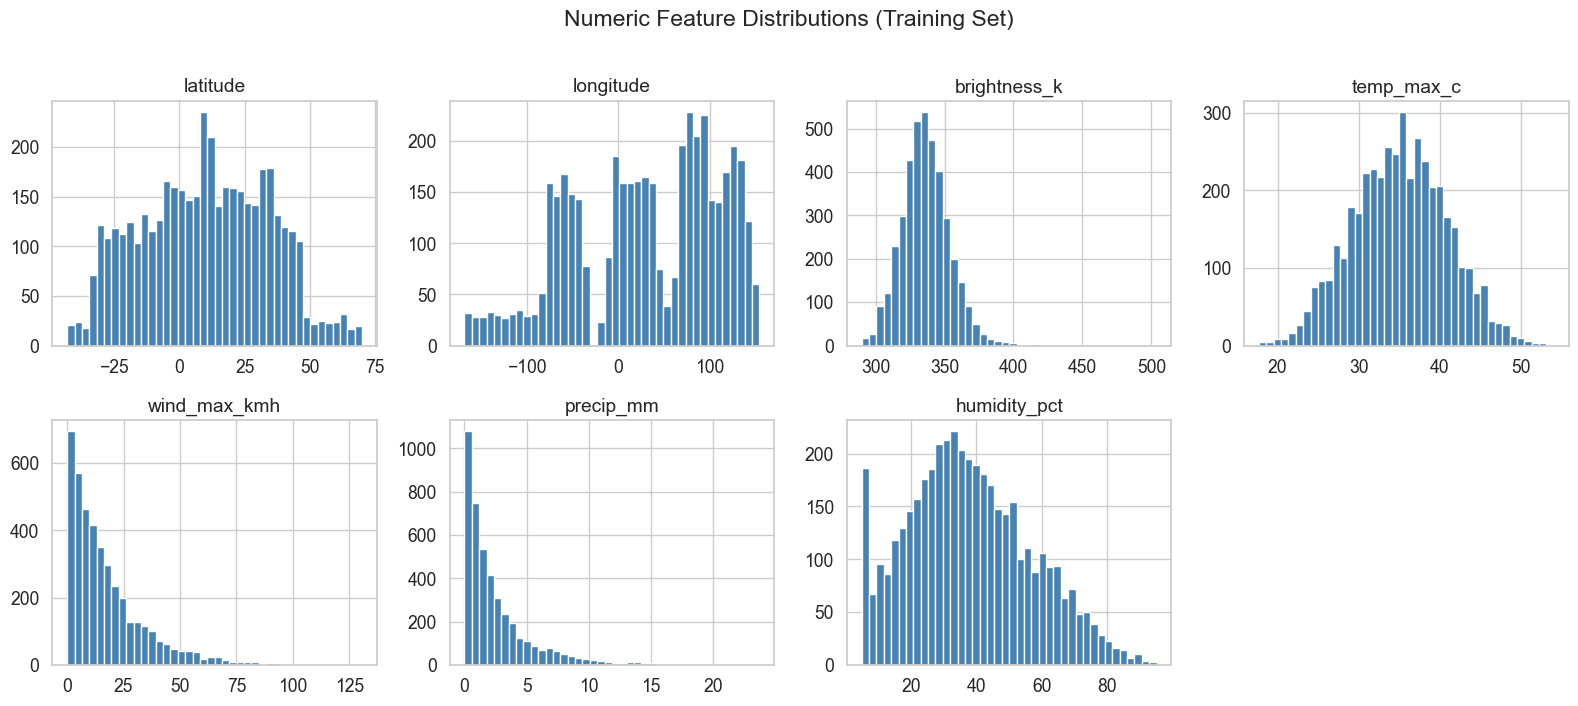

In [29]:
num_cols = ['latitude', 'longitude', 'brightness_k',
            'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_tr[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions (Training Set)', y=1.01)
plt.tight_layout()
plt.show()

# ANALYSIS NOTE ─────────────────────────────────────────────────────────────
# Mention skewed features (e.g. precip_mm often right-skewed).
# SVM and NN are sensitive to feature scale → StandardScaler is essential.

The above numeric feature histogram and summary statistic inspection reveals two main characteristics that would influence the data preprocessing pipeline, which are **skewness**, and **variance of magnitudes**.

**Strong Right-skewness**:
> Features such as `wind_max_kmh`, and `precip_mm` show significant skewness to the right. The vast majority of the data are shown to be clustered at the lower end whereas the long tail represents the rarer, yet extreme weather events.

> Impact: Strongly skewed data could potentially obstruct models when converging. Even though **Decision Trees** are robust to this, **Neural nets** tend to prefer more symmetric input.

**Scale Disparity**:
>  A massive difference in numerical ranges across features is present. For example, `brightness_k`values are centered around the $340 K$ mark whereas `precip_mm` values are mostly below $5mm$.

> Impact: **SVM**s which use distance based kernels, and **Neural Nets** which use gradient optimization are considerably sensitive to these scales. If no measure was taken, the models would treat (mathematically) `brightness_k` as significantly more important than `precip_mm`, simply because the numbers are larger.

Strategy for PreprocessingTo mitigate the issues identified above, the following techniques will be implemented:Outlier-Robust Imputation: We will use Median Imputation for missing values in skewed features like brightness_k and wind_max_kmh. Unlike the mean, the median is not dragged by the "long tails" of extreme weather events, ensuring our imputed data remains representative of typical fire conditions.Feature Standardization: We will apply StandardScaler to all numeric inputs. By shifting the mean to $0$ and scaling to unit variance (standard deviation of $1$), we "level the playing field." This ensures the SVM and Neural Network can converge efficiently without being biased by the raw magnitude of features like brightness_k.

### Numerical features vs Target (Box-plots)

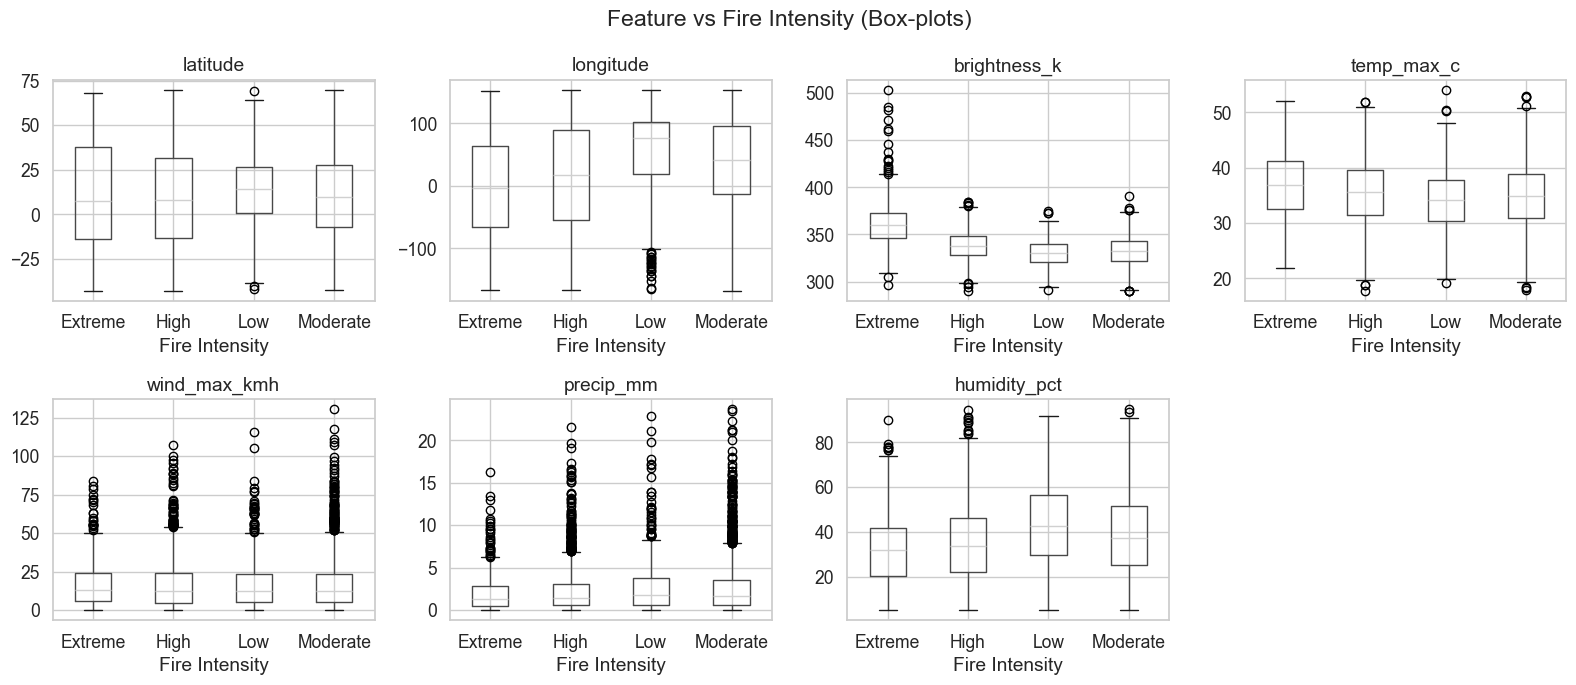

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df_tr.boxplot(column=col, by='fire_intensity', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Fire Intensity')
axes[-1].set_visible(False)
plt.suptitle('Feature vs Fire Intensity (Box-plots)')
plt.tight_layout()
plt.show()

# NOTE: The intensities go from Extreme -> High -> Low --then--> Moderate

To understand the discriminative properties of features for fire intensity classification, box-plots were generated for each numerical features across the intensity classes as above.

Important Observations:
> As the basic physics behind combustion suggests, `brightness_k` shows clear upward trend as intensity reaches the 'Extreme'. A significantly higher median brightness and a large number of higher value outliers are present in the 'Extreme' class, suggesting this would act as a primary predictor for the models.

> It is also important to note the behaviour of weather dynamics.
> - Looking at `temp_max_c`, higher fire intensity classes generally match with higher *max* air tempratures.
> - The inverse relationship of `humidity_pct` with intensity classes where it suggests higher intensity fires usually happen at lower humidity levels aligns with fire behaviour as dry fuel and air facilitate intense fires.

> The distribution of geographic coordinates (`logitude`/`latitude`) showcases a distict 'tightness' in some classes, hinting that fire intensity classes are very likely tied to certain climatic regions or types of fuel that can only be found in specific locations (logitudes/latitudes).

> Unlike other features , wind speed (`wind_max_kmh`) fail to show noticable differences in medians or interquartile range across the fire intensity classes. This leads to believe that `wind_max_kmh` is a noisy predictor. however, the significant outlier presense of all four classes, noticably 'High', 'Low', 'Moderate' classes reaching beyond $100 km/h$, indicates that even though wind influence fire bahaviour, it likely acts as a *secondary driver*.


After the above analysis, the clear seperation in `brightness_k`, and the overall clear and consistent trends in weather variables provide confirmation that the features contain sufficient enough signal for classification. The numeraous outlier presense in higher intensity classes strengthen the justification of using `StandardScalar` to normalise these distributions for the Neural Net and SVM, whereas the Decision Tree will natural handle the non-linear thresholds.

### Correlation Heatmap (Numerical Features)

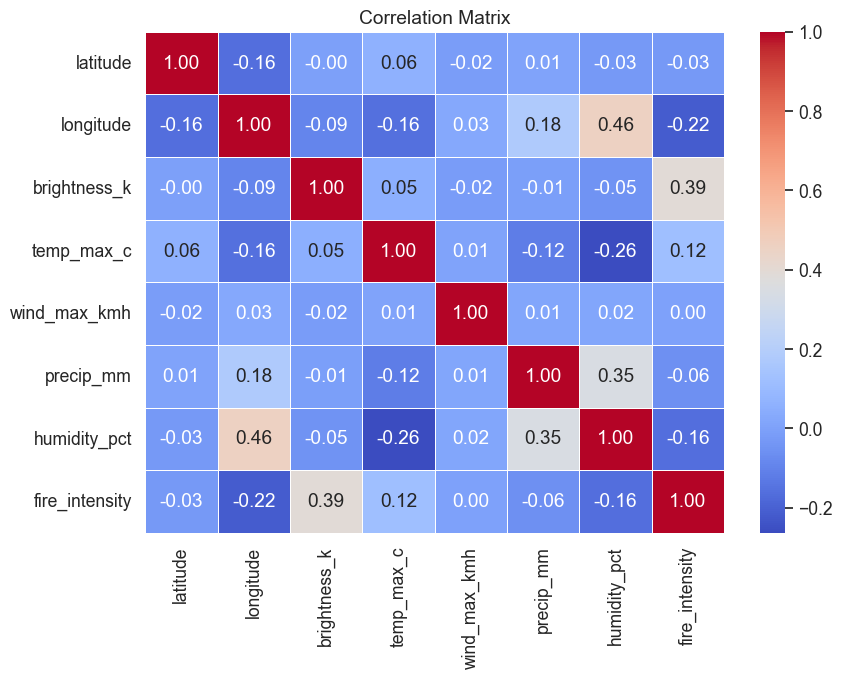

In [33]:
# map string labels to integers
label_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3}
df_tr['fire_intensity'] = df_tr['fire_intensity'].map(label_map).fillna(df_tr['fire_intensity']).astype(int)

corr = df_tr[num_cols + ['fire_intensity']].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# ANALYSIS NOTE ─────────────────────────────────────────────────────────────
# Identify the top 2-3 features correlated with fire_intensity.
# Note any multi-collinearity (may not affect tree models but affects SVM).

A Pearson Correlation Matrix was generated to quantify the linear relationships present between numerical features and the target.

Identified **top predictors** for fire intensity:
1. `brightness_k` (0.39): This holds the stringest positive correlation. This is confirmation that brightness temprature is the most reliable linear predictor of the intensity of fire also aligning with the previous discoveries.
2. `longitude` (-0.22): This clear negative correlation indicates that, in this particular dataset, fires tend located to the further West, to be of higher intensity. Likely, this is due to regional climate patterns or vegetation types tied to those coordinates.
3. `humidity_pct` (-0.16): This negative correlation between humidity and fire intensity aligns with our previous findings, since lower moisture levels in air harbour more aggressive and intense fires.

Identified **multi-colinearity** observations:
- `humidity_pct` and `longitude` (0.46): This somewhat moderate of a positive correlation suggests that humidity levels are strongly tied to geographic locations in this dataset.
- `humidity_pct` and `precip_mm` (0.35): This showcases a rather logical relationship where higher precipitation correlates with higher humidity.
- `temp_max_c` and `humidity_pct` (-0.26): This is a very typical negative correlation (inverse relationship) found in weather data.

Impact on the Models:
> **Decision Trees**: These models generally tend to be immune to multi-colinearity, since they split on one single feature at a time. Therefore, correlations like the one between `humidity_pct` and `longitude` will not confuse the model (tree).

> **Neural Nets and SVMs**: These are the models that has the risk of being sensitive to high correlated features. With correlated features like `humidity_pct` and `longitude` move together at the same time, the SVM decision boundary has the potential of being less stable. However, since even the highest correlation of 0.46 is below the typical danger zone of 0.70 upward, all the features can be safely kept for the initial training phase.


An important thing to note is the **correlation between `fire_intensity` and `wind_max_kmh`**, where it is 0. This clearly align with what we discovered in the previous box-plot analysis, that wind speed is a *non-linear* factor.

### Categorical feature counts

In [ ]:
cat_cols = ['season', 'daynight', 'region', 'fire_type', 'satellite',
            'instrument', 'confidence']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc2 = df_tr[col].value_counts()
    axes[i].bar(vc2.index.astype(str), vc2.values, color='coral')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions')
plt.tight_layout()
plt.show()